# MobileNetV2 Vegetable Classification V4 — 128x128 input, larger video dataset

V4 mirrors V3's architecture and training recipe but scales the input resolution and the
amount of supervision per video clip. Changes vs V3:

- **Input size 96 → 128.** MobileNetV2-0.35 still fits on the ESP32S3 at 128x128
  (~700 KB TFLite, tensor arena ~400 KB). The extra resolution helps disambiguate
  texture-heavy classes (Broccoli vs Cabbage florets, Garlic vs Onion skin).
- **Frames per video 30 → 60.** The user added more clips, so we double the per-video
  sampling density to keep training volume up. Balance is preserved automatically:
  Cell 2c caps Unknown at the **largest** positive count, and Cell 6 reweights the loss
  inversely to current per-class file counts, so a heavier video presence in some
  classes does not collapse the model onto them.
- **Phase 2 fine-tuning re-enabled** (`EPOCHS_FINETUNE = 15`). With more frames per
  class, fine-tuning the top of MobileNetV2 stops being a pure overfit risk and gives
  another 1–3 pp on val.
- **No SenseCraft / Vela exports.** V4 only produces the int8 TFLite + C headers
  consumed by `src/main/`.

In [19]:
# Cell 1: Install and Import
get_ipython().system('pip install -q tensorflow matplotlib seaborn scikit-learn pillow opencv-python')

In [20]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Configuration
IMG_SIZE = 128                 # V4: bumped from 96 to 128 for finer texture cues
ALPHA = 0.35                   # Width multiplier - 0.35 is the smallest pretrained variant
EPOCHS_HEAD = 25               # Phase 1: train classification head with frozen base
EPOCHS_FINETUNE = 15           # Phase 2: re-enabled with the larger dataset
BATCH_SIZE = 32
CONFIDENCE_THRESHOLD = 0.9
NUM_CLASSES = 10
FINE_TUNE_AT = 100             # Unfreeze layers from this index onwards in phase 2

# 9 named veggies + Unknown catch-all class for non-target objects.
SELECTED_CLASSES = [
    'Bellpepper', 'Broccoli', 'Cabbage', 'Carrot',
    'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato',
    'Unknown',
]

# Paths: data lives at veggie_classification/data/huggingface
BASE_DIR = Path('..') / '..' / 'data' / 'huggingface'
TRAIN_DIR = BASE_DIR / 'Train'
VAL_DIR = BASE_DIR / 'val'

# User-recorded videos (filename prefix encodes class). Frames get mixed into the train split only.
VIDEO_DIR = Path('..') / '..' / 'data' / 'videos'

# Optional supplementary stills for the Unknown class (cups, hands, packaging, etc.).
UNKNOWN_DIR = Path('..') / '..' / 'data' / 'unknown'

# Keras image_dataset_from_directory reads classes from a single folder - mirror YOLO layout
MNV2_DATASET = Path('mnv2_dataset')
RUN_DIR = Path('runs') / 'veggie_mnv2'
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f'TensorFlow: {tf.__version__}')
print(f'OpenCV: {cv2.__version__}')
print(f'GPU available: {bool(tf.config.list_physical_devices("GPU"))}')
print(f'Selected classes: {SELECTED_CLASSES}')

TensorFlow: 2.19.1
OpenCV: 4.11.0
GPU available: False
Selected classes: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato', 'Unknown']


In [21]:
# Cell 2: Prepare dataset - copy 9 named veggie classes from HuggingFace into mnv2_dataset/.
# (The Unknown class is built separately by Cell 2c.)

NAMED_CLASSES = [c for c in SELECTED_CLASSES if c != 'Unknown']

for split, src_dir in [('train', TRAIN_DIR), ('val', VAL_DIR)]:
    for cls in NAMED_CLASSES:
        dst = MNV2_DATASET / split / cls
        src = src_dir / cls
        if dst.is_symlink():
            dst.unlink()
        if dst.exists():
            continue
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copytree(src, dst)
        print(f'Copied: {src} -> {dst}')

# Clean any stray cache folders that image_dataset_from_directory would pick up as classes.
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    for entry in split_dir.iterdir():
        if entry.name not in SELECTED_CLASSES:
            print(f'Removing non-class entry: {entry}')
            if entry.is_dir():
                shutil.rmtree(entry)
            else:
                entry.unlink()

print('\n=== Dataset Summary ===')
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(list((split_dir / cls).glob('*')))
        total += count
        print(f'  {split}/{cls}: {count} images')
    print(f'  Total {split}: {total}\n')

Copied: ../../data/huggingface/Train/Bellpepper -> mnv2_dataset/train/Bellpepper
Copied: ../../data/huggingface/Train/Broccoli -> mnv2_dataset/train/Broccoli
Copied: ../../data/huggingface/Train/Cabbage -> mnv2_dataset/train/Cabbage
Copied: ../../data/huggingface/Train/Carrot -> mnv2_dataset/train/Carrot
Copied: ../../data/huggingface/Train/Eggplant -> mnv2_dataset/train/Eggplant
Copied: ../../data/huggingface/Train/Garlic -> mnv2_dataset/train/Garlic
Copied: ../../data/huggingface/Train/Onion -> mnv2_dataset/train/Onion
Copied: ../../data/huggingface/Train/Potato -> mnv2_dataset/train/Potato
Copied: ../../data/huggingface/Train/Tomato -> mnv2_dataset/train/Tomato
Copied: ../../data/huggingface/val/Bellpepper -> mnv2_dataset/val/Bellpepper
Copied: ../../data/huggingface/val/Broccoli -> mnv2_dataset/val/Broccoli
Copied: ../../data/huggingface/val/Cabbage -> mnv2_dataset/val/Cabbage
Copied: ../../data/huggingface/val/Carrot -> mnv2_dataset/val/Carrot
Copied: ../../data/huggingface/val/Eg

In [22]:
# Cell 2b: Augment train set with frames sampled from user-recorded videos.
# Filename prefix encodes the class (handles typos bellpaper / bellpeper -> Bellpepper).
# Frames are written only into the TRAIN split so validation stays honest.
#
# V4: FRAMES_PER_VIDEO doubled from 30 -> 60. With more clips per class now available,
# this gives roughly one frame per 0.5s on a 30s clip. Cell 2c (Unknown cap) and the
# class_weight in Cell 6 both recompute from current per-class counts, so the heavier
# video presence in classes the user filmed more (e.g. Cabbage) is rebalanced
# automatically and does not bias the model.

VIDEO_CLASS_MAP = {
    'bellpaper':  'Bellpepper',
    'bellpeper':  'Bellpepper',
    'bellpepper': 'Bellpepper',
    'broccoli':   'Broccoli',
    'cabbage':    'Cabbage',
    'carrot':     'Carrot',
    'eggplant':   'Eggplant',
    'garlic':     'Garlic',
    'onion':      'Onion',
    'potato':     'Potato',
    'tomato':     'Tomato',
    'unknown':    'Unknown',     # cups, hands, packaging, fridge interior, etc.
}
FRAMES_PER_VIDEO = 60          # V4: was 30

def class_from_filename(name: str):
    stem = Path(name).stem.lower()
    prefix = stem.split('_', 1)[0]
    return VIDEO_CLASS_MAP.get(prefix)

def center_square_crop(frame):
    h, w = frame.shape[:2]
    side = min(h, w)
    y0, x0 = (h - side) // 2, (w - side) // 2
    return frame[y0:y0 + side, x0:x0 + side]

video_counts = {}
if not VIDEO_DIR.exists():
    print(f'No video dir at {VIDEO_DIR} - skipping video augmentation.')
else:
    for video_path in sorted(VIDEO_DIR.iterdir()):
        if video_path.suffix.lower() not in {'.mp4', '.mov', '.avi', '.mkv'}:
            continue
        cls = class_from_filename(video_path.name)
        if cls is None:
            print(f'[skip] unknown class for {video_path.name}')
            continue

        dst_dir = MNV2_DATASET / 'train' / cls
        dst_dir.mkdir(parents=True, exist_ok=True)

        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            print(f'[skip] cannot read {video_path.name}')
            cap.release()
            continue

        step = max(1, total_frames // FRAMES_PER_VIDEO)
        saved = 0
        target = min(FRAMES_PER_VIDEO, total_frames)
        for i in range(target):
            frame_idx = min(i * step, total_frames - 1)
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ok, frame = cap.read()
            if not ok:
                continue
            frame = center_square_crop(frame)
            out_path = dst_dir / f'{video_path.stem}_f{frame_idx:06d}.jpg'
            cv2.imwrite(str(out_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 92])
            saved += 1
        cap.release()

        video_counts[video_path.name] = (cls, saved)
        print(f'{video_path.name:30s} -> {cls:10s} ({saved} frames)')

print('\n=== Dataset after video augmentation ===')
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(list((split_dir / cls).glob('*')))
        total += count
        print(f'  {split}/{cls}: {count} images')
    print(f'  Total {split}: {total}\n')

bellpaper_2.mp4                -> Bellpepper (60 frames)
bellpeper_1.mp4                -> Bellpepper (60 frames)
bellpepper_3.mp4               -> Bellpepper (60 frames)
broccoli_1.mp4                 -> Broccoli   (60 frames)
cabbage_1.mp4                  -> Cabbage    (60 frames)
cabbage_2.mp4                  -> Cabbage    (60 frames)
cabbage_3.mp4                  -> Cabbage    (60 frames)
carrot_1.mp4                   -> Carrot     (60 frames)
carrot_2.mp4                   -> Carrot     (60 frames)
[skip] unknown class for cucumber_1.mp4
eggplant_1.mp4                 -> Eggplant   (60 frames)
eggplant_2.mp4                 -> Eggplant   (60 frames)
onion_1.mp4                    -> Onion      (60 frames)
tomato_1.mp4                   -> Tomato     (60 frames)
tomato_2.mp4                   -> Tomato     (60 frames)

=== Dataset after video augmentation ===
  train/Bellpepper: 270 images
  train/Broccoli: 140 images
  train/Cabbage: 272 images
  train/Carrot: 202 images
  tra

In [23]:
# Cell 2c: assemble the Unknown class.
#   Source A (primary): N stills/class from HuggingFace classes NOT in our 9 named ones.
#                       Same lighting/backgrounds as positives, so the model learns
#                       "this is not one of my 9", not "different background style".
#                       Specifically targets the reported failure modes - red things
#                       (Apple/Strawberry/Pomegranate/Chilli pepper/Raspberry) and
#                       purple things (Beetroot).
#   Source B (optional): all stills the user dropped into data/unknown/ (cups, hands,
#                        packaging, etc. - items the HF dataset doesn't cover).
# Cell 2b separately handles unknown_*.mp4 video frames.
#
# IMPORTANT: this cell now runs AFTER Cell 2b so the "largest positive class" cap reflects
# the post-video counts. With 60 frames/video, positives swell, so Unknown can be
# sampled more aggressively from HF without hitting the cap.

UNKNOWN_PER_HF_CLASS_TRAIN = 8     # was 5 in V3 - more headroom now positives are larger
UNKNOWN_PER_HF_CLASS_VAL   = 1

# Aliases / dropped classes that must NOT be sampled into Unknown.
HF_EXCLUDE = set(NAMED_CLASSES) | {
    'Bell pepper', 'Capsicum',   # alt names for Bellpepper
    'Sweetcorn',                 # alias for Corn
    'Cucumber',                  # dropped in V3, but reserved (don't poison Unknown)
}

unknown_train = MNV2_DATASET / 'train' / 'Unknown'
unknown_val   = MNV2_DATASET / 'val'   / 'Unknown'
unknown_train.mkdir(parents=True, exist_ok=True)
unknown_val.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
n_hf_train = n_hf_val = 0
for split, src_root, n_per, dst in [
    ('train', TRAIN_DIR, UNKNOWN_PER_HF_CLASS_TRAIN, unknown_train),
    ('val',   VAL_DIR,   UNKNOWN_PER_HF_CLASS_VAL,   unknown_val),
]:
    if not src_root.exists():
        continue
    for cls_dir in sorted(src_root.iterdir()):
        if not cls_dir.is_dir() or cls_dir.name in HF_EXCLUDE:
            continue
        files = sorted(p for p in cls_dir.iterdir()
                       if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'})
        if not files:
            continue
        picks = rng.choice(files, size=min(n_per, len(files)), replace=False)
        for src in picks:
            dst_path = dst / f'{cls_dir.name}__{src.name}'
            if not dst_path.exists():
                shutil.copy(src, dst_path)
                if split == 'train':
                    n_hf_train += 1
                else:
                    n_hf_val += 1

print(f'Unknown from HuggingFace: {n_hf_train} train / {n_hf_val} val')

# Source B - user-supplied stills (optional). Enabled in V4 since user has populated data/unknown/.
n_user_train = n_user_val = 0
if UNKNOWN_DIR.exists():
    user_files = sorted(p for p in UNKNOWN_DIR.iterdir()
                        if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'})
    rng2 = np.random.default_rng(SEED + 1)
    rng2.shuffle(user_files)
    n_val_user = max(0, len(user_files) // 10)
    for i, src in enumerate(user_files):
        if i < n_val_user:
            dst_path = unknown_val / f'user__{src.name}'
            n_user_val += 1
        else:
            dst_path = unknown_train / f'user__{src.name}'
            n_user_train += 1
        if not dst_path.exists():
            shutil.copy(src, dst_path)
    print(f'Unknown from data/unknown/: {n_user_train} train / {n_user_val} val')
else:
    print(f'(No {UNKNOWN_DIR} - skipping user supplementary source)')

# Cap Unknown train to the LARGEST positive class count so the model can't lazily
# default to Unknown. Random downsample is seeded for reproducibility. Val left alone.
positive_train_counts = [
    len(list((MNV2_DATASET / 'train' / cls).glob('*')))
    for cls in NAMED_CLASSES
]
target_unknown_train = int(np.max(positive_train_counts))
unknown_files = sorted(unknown_train.glob('*'))
if len(unknown_files) > target_unknown_train:
    rng3 = np.random.default_rng(SEED + 2)
    drop_idx = set(rng3.choice(len(unknown_files),
                               size=len(unknown_files) - target_unknown_train,
                               replace=False).tolist())
    n_dropped = 0
    for i, f in enumerate(unknown_files):
        if i in drop_idx:
            f.unlink()
            n_dropped += 1
    print(f'Balanced Unknown train: capped at {target_unknown_train} '
          f'(max of positive classes); dropped {n_dropped} excess images.')
else:
    print(f'Unknown train ({len(unknown_files)}) already <= max positive '
          f'({target_unknown_train}); no rebalance needed.')

print(f'\nUnknown class total: '
      f'{len(list(unknown_train.glob("*")))} train / '
      f'{len(list(unknown_val.glob("*")))} val')

Unknown from HuggingFace: 312 train / 39 val
Unknown from data/unknown/: 178 train / 19 val
Balanced Unknown train: capped at 272 (max of positive classes); dropped 218 excess images.

Unknown class total: 272 train / 58 val


In [24]:
# Cell 2d: hard guarantee that every file in mnv2_dataset is decodable.
#
# Keras image_dataset_from_directory uses tf.io.decode_image, which accepts
# only JPEG / PNG / GIF / BMP via magic bytes. PIL is more permissive (it'll
# happily decode WebP or TIFF), so PIL-based filtering can let bad files
# through. This sweep uses tf.io.decode_image itself - anything that survives
# here will not crash training.
#
# Re-run this cell any time you see "Unknown image file format" during
# model.fit. It is idempotent: clean datasets pass through untouched.

import tensorflow as tf  # already imported above; re-imported for cell-level safety

def is_tf_decodable(path):
    try:
        tf.io.decode_image(tf.io.read_file(str(path)))
        return True
    except Exception:
        return False

removed = []
for f in MNV2_DATASET.rglob('*'):
    if not f.is_file():
        continue
    if not is_tf_decodable(f):
        removed.append(f)
        f.unlink()

print(f'Scanned mnv2_dataset/: removed {len(removed)} non-decodable files')
for f in removed:
    print(f'  - {f.relative_to(MNV2_DATASET)}')

print()
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    total = sum(len(list((split_dir / cls).glob('*'))) for cls in os.listdir(split_dir))
    print(f'  {split}: {total} files across {len(os.listdir(split_dir))} classes')

2026-05-12 11:46:33.785067: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:34.376446: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:38.721546: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:45.060230: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:46.606393: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:46.995810: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:48.033375: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:49.077784: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


Scanned mnv2_dataset/: removed 0 non-decodable files

  train: 1895 files across 10 classes
  val: 153 files across 10 classes


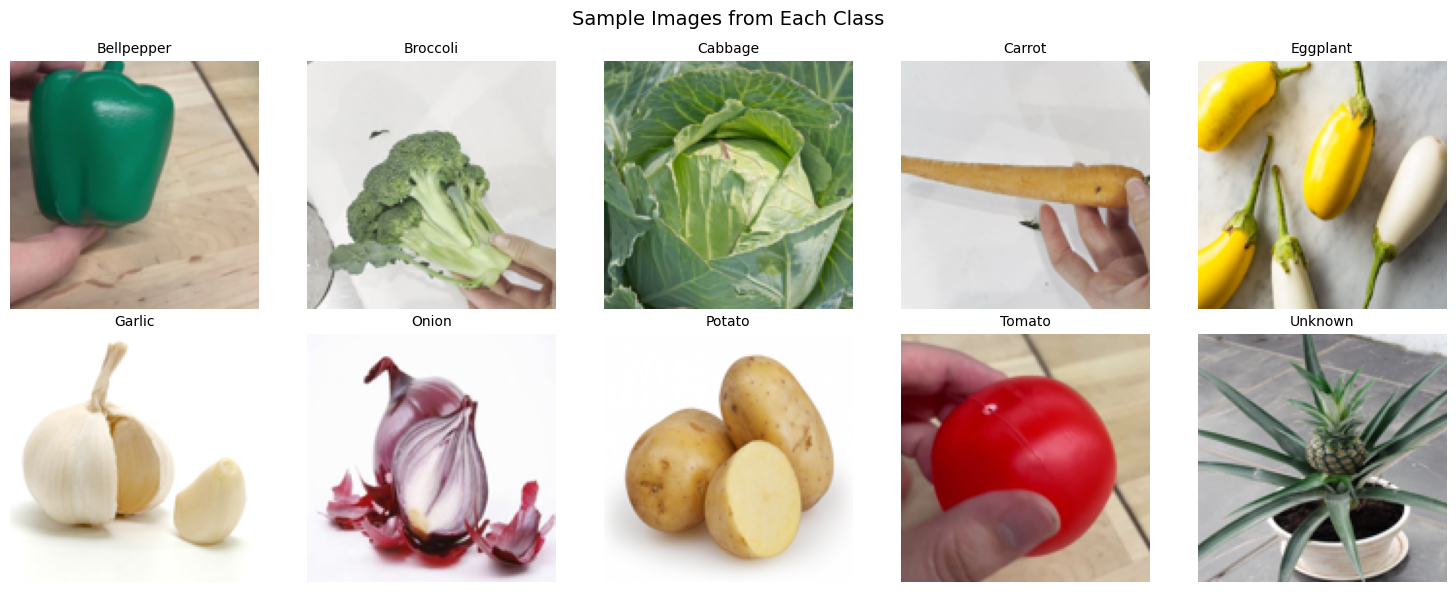

In [25]:
# Cell 3: Visualize sample images

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(SELECTED_CLASSES):
    ax = axes[i // 5, i % 5]
    cls_path = MNV2_DATASET / 'train' / cls
    img_path = list(cls_path.glob('*'))[0]
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# Cell 4: Build tf.data pipelines with augmentation

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    MNV2_DATASET / 'train',
    labels='inferred',
    label_mode='int',
    class_names=SELECTED_CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    MNV2_DATASET / 'val',
    labels='inferred',
    label_mode='int',
    class_names=SELECTED_CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = list(train_ds_raw.class_names)
print(f'class_names: {class_names}')

# Geometric + mild color augmentation. Same ranges as V3 - tighter hue/sat to keep
# Bellpepper/Tomato distinguishable. RandomHue/RandomSaturation are missing from
# some Keras builds, so we wrap tf.image.* in a Lambda.
def random_hue_sat(x):
    x = tf.cast(x, tf.float32) / 255.0
    x = tf.image.random_hue(x, max_delta=0.03)
    x = tf.image.random_saturation(x, lower=0.9, upper=1.1)
    return tf.clip_by_value(x, 0.0, 1.0) * 255.0

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.25),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
    layers.Lambda(random_hue_sat, name='random_hue_sat'),
], name='data_augmentation')

AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, training):
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    # MobileNetV2 expects inputs scaled to [-1, 1]
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds_raw, training=True)
val_ds = prepare(val_ds_raw, training=False)

for imgs, labels in train_ds.take(1):
    print(f'Batch shape: {imgs.shape}, range [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]')
    print(f'Labels: {labels.numpy()}')

Found 1895 files belonging to 10 classes.
Found 153 files belonging to 10 classes.
class_names: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato', 'Unknown']
Batch shape: (32, 128, 128, 3), range [-1.00, 1.00]
Labels: [4 9 3 5 0 1 1 5 0 2 6 2 2 5 2 8 2 1 4 0 6 1 8 6 9 6 1 2 8 7 2 3]


2026-05-12 11:46:54.839452: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [27]:
# Cell 5: Build MobileNetV2 transfer-learning model (128x128 input)

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    alpha=ALPHA,
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input')
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
x = layers.Dropout(0.5, name='dropout')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = models.Model(inputs, outputs, name='mnv2_veggie')
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "mnv2_veggie"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_128            │ (None, 4, 4, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,018 (1.61 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 410,208 (1.56 MB)

In [28]:
# Cell 6: Phase 1 - train classification head (base frozen)

ckpt_path = RUN_DIR / 'best_head.keras'
cb = [
    callbacks.ModelCheckpoint(str(ckpt_path), monitor='val_accuracy',
                              save_best_only=True, mode='max'),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                            mode='max', restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
]

# Class weights from current train file counts. Recomputed every run so it tracks
# however the video sampling and Unknown cap landed for this dataset.
import collections
_counts = collections.Counter()
for _, lbls in train_ds_raw:
    for v in lbls.numpy().tolist():
        _counts[v] += 1
_total = sum(_counts.values())
class_weight = {i: _total / (NUM_CLASSES * max(_counts[i], 1))
                for i in range(NUM_CLASSES)}
print('class_weight:', {class_names[i]: f'{w:.2f}' for i, w in class_weight.items()})

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=cb,
    class_weight=class_weight,
    verbose=2,
)

2026-05-12 11:46:55.130844: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:55.578701: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:55.721048: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:56.347342: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:56.411466: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:56.953756: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:57.035814: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:46:57.577339: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


class_weight: {'Bellpepper': '0.70', 'Broccoli': '1.35', 'Cabbage': '0.70', 'Carrot': '0.94', 'Eggplant': '0.93', 'Garlic': '2.06', 'Onion': '1.23', 'Potato': '2.46', 'Tomato': '0.89', 'Unknown': '0.70'}
Epoch 1/25


2026-05-12 11:47:00.363134: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:47:00.790847: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:47:00.874180: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:47:01.012828: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:47:01.402861: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:47:01.975757: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:47:02.802132: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:47:03.724403: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


60/60 - 8s - 132ms/step - accuracy: 0.4401 - loss: 1.7199 - val_accuracy: 0.6863 - val_loss: 0.8852 - learning_rate: 1.0000e-03
Epoch 2/25
60/60 - 2s - 26ms/step - accuracy: 0.7198 - loss: 0.8272 - val_accuracy: 0.8039 - val_loss: 0.6159 - learning_rate: 1.0000e-03
Epoch 3/25
60/60 - 2s - 29ms/step - accuracy: 0.7789 - loss: 0.6227 - val_accuracy: 0.8301 - val_loss: 0.5434 - learning_rate: 1.0000e-03
Epoch 4/25
60/60 - 2s - 28ms/step - accuracy: 0.8169 - loss: 0.4906 - val_accuracy: 0.8627 - val_loss: 0.4805 - learning_rate: 1.0000e-03
Epoch 5/25
60/60 - 2s - 26ms/step - accuracy: 0.8522 - loss: 0.4454 - val_accuracy: 0.8758 - val_loss: 0.4852 - learning_rate: 1.0000e-03
Epoch 6/25
60/60 - 1s - 24ms/step - accuracy: 0.8549 - loss: 0.3939 - val_accuracy: 0.8889 - val_loss: 0.4489 - learning_rate: 1.0000e-03
Epoch 7/25
60/60 - 1s - 23ms/step - accuracy: 0.8770 - loss: 0.3533 - val_accuracy: 0.8693 - val_loss: 0.4493 - learning_rate: 1.0000e-03
Epoch 8/25
60/60 - 1s - 22ms/step - accuracy

In [29]:
# Cell 7: Phase 2 - fine-tune top layers of MobileNetV2
# Re-enabled in V4 because the larger train set (more video frames) supports it
# without immediate overfit. AdamW + small LR + EarlyStopping(restore_best) keeps it honest.

ckpt_path_ft   = RUN_DIR / 'best.keras'
ckpt_path_head = RUN_DIR / 'best_head.keras'

if EPOCHS_FINETUNE == 0:
    print('Phase 2 disabled (EPOCHS_FINETUNE=0). Using Phase 1 best as final model.')
    if ckpt_path_head.exists():
        shutil.copy(ckpt_path_head, ckpt_path_ft)
    else:
        model.save(ckpt_path_ft)
    history_ft = type('H', (), {'history': {}})()
    print(f'Best model saved to: {ckpt_path_ft}')
else:
    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f'Base layers total: {len(base_model.layers)}, trainable: {trainable_count}')

    model.compile(
        optimizer=optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    cb_ft = [
        callbacks.ModelCheckpoint(str(ckpt_path_ft), monitor='val_accuracy',
                                  save_best_only=True, mode='max'),
        callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                mode='max', restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ]

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINETUNE,
        callbacks=cb_ft,
        class_weight=class_weight,
        verbose=2,
    )

    if not ckpt_path_ft.exists():
        model.save(ckpt_path_ft)
    print(f'Best model saved to: {ckpt_path_ft}')

Base layers total: 154, trainable: 54
Epoch 1/15
60/60 - 6s - 99ms/step - accuracy: 0.7472 - loss: 0.6941 - val_accuracy: 0.7516 - val_loss: 0.8042 - learning_rate: 1.0000e-04
Epoch 2/15
60/60 - 2s - 37ms/step - accuracy: 0.8559 - loss: 0.3685 - val_accuracy: 0.7778 - val_loss: 0.7712 - learning_rate: 1.0000e-04
Epoch 3/15
60/60 - 2s - 37ms/step - accuracy: 0.9013 - loss: 0.2703 - val_accuracy: 0.7778 - val_loss: 0.7447 - learning_rate: 1.0000e-04
Epoch 4/15
60/60 - 2s - 41ms/step - accuracy: 0.9203 - loss: 0.2111 - val_accuracy: 0.7908 - val_loss: 0.6988 - learning_rate: 1.0000e-04
Epoch 5/15
60/60 - 2s - 39ms/step - accuracy: 0.9409 - loss: 0.1695 - val_accuracy: 0.8170 - val_loss: 0.6519 - learning_rate: 1.0000e-04
Epoch 6/15
60/60 - 2s - 39ms/step - accuracy: 0.9615 - loss: 0.1262 - val_accuracy: 0.8301 - val_loss: 0.6321 - learning_rate: 1.0000e-04
Epoch 7/15
60/60 - 2s - 38ms/step - accuracy: 0.9678 - loss: 0.1091 - val_accuracy: 0.8105 - val_loss: 0.6606 - learning_rate: 1.0000e

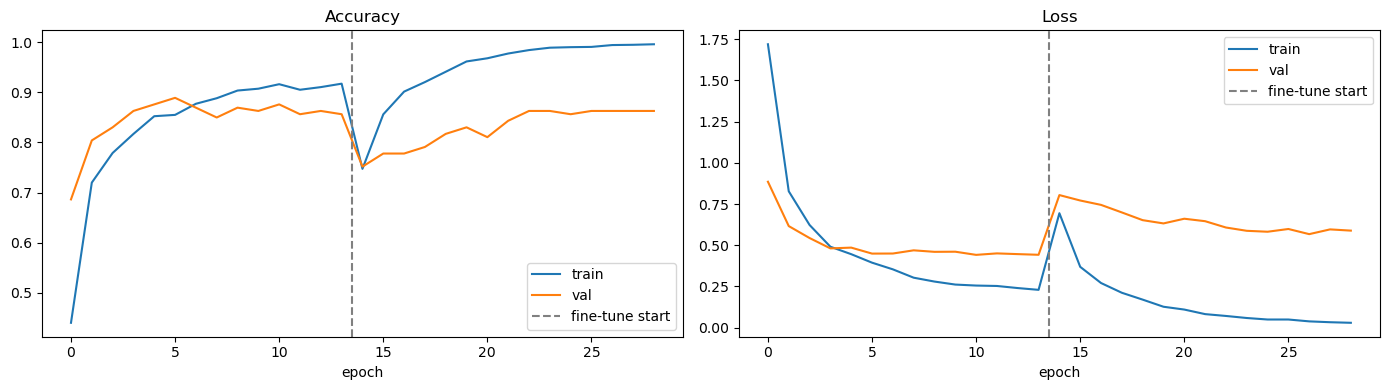

In [30]:
# Cell 8: Training curves

def merge(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc = merge(history_head, history_ft, 'accuracy')
val_acc = merge(history_head, history_ft, 'val_accuracy')
loss = merge(history_head, history_ft, 'loss')
val_loss = merge(history_head, history_ft, 'val_loss')
boundary = len(history_head.history.get('accuracy', []))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(acc, label='train')
axes[0].plot(val_acc, label='val')
axes[0].axvline(boundary - 0.5, color='gray', linestyle='--', label='fine-tune start')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(loss, label='train')
axes[1].plot(val_loss, label='val')
axes[1].axvline(boundary - 0.5, color='gray', linestyle='--', label='fine-tune start')
axes[1].set_title('Loss'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(RUN_DIR / 'training_curves.png', dpi=120)
plt.show()

In [31]:
# Cell 9: Evaluate on validation set

best_model = tf.keras.models.load_model(ckpt_path_ft)
val_loss_final, val_acc_final = best_model.evaluate(val_ds, verbose=0)
print(f'Top-1 Accuracy: {val_acc_final:.4f}')
print(f'Val Loss:       {val_loss_final:.4f}')

Top-1 Accuracy: 0.8627
Val Loss:       0.6072


Predictions below threshold (0.9): 37/153
These would be "Object not known"

=== Classification Report (confident predictions) ===
              precision    recall  f1-score   support

  Bellpepper       1.00      1.00      1.00         5
    Broccoli       1.00      0.94      0.97        16
     Cabbage       0.91      1.00      0.95        10
      Carrot       1.00      0.89      0.94         9
    Eggplant       1.00      1.00      1.00         8
      Garlic       0.91      1.00      0.95        10
       Onion       0.75      1.00      0.86         6
      Potato       1.00      0.88      0.93         8
      Tomato       0.91      1.00      0.95        10
     Unknown       0.94      0.88      0.91        34

    accuracy                           0.94       116
   macro avg       0.94      0.96      0.95       116
weighted avg       0.95      0.94      0.94       116

=== Classification Report (all predictions) ===
              precision    recall  f1-score   support

  Bellp

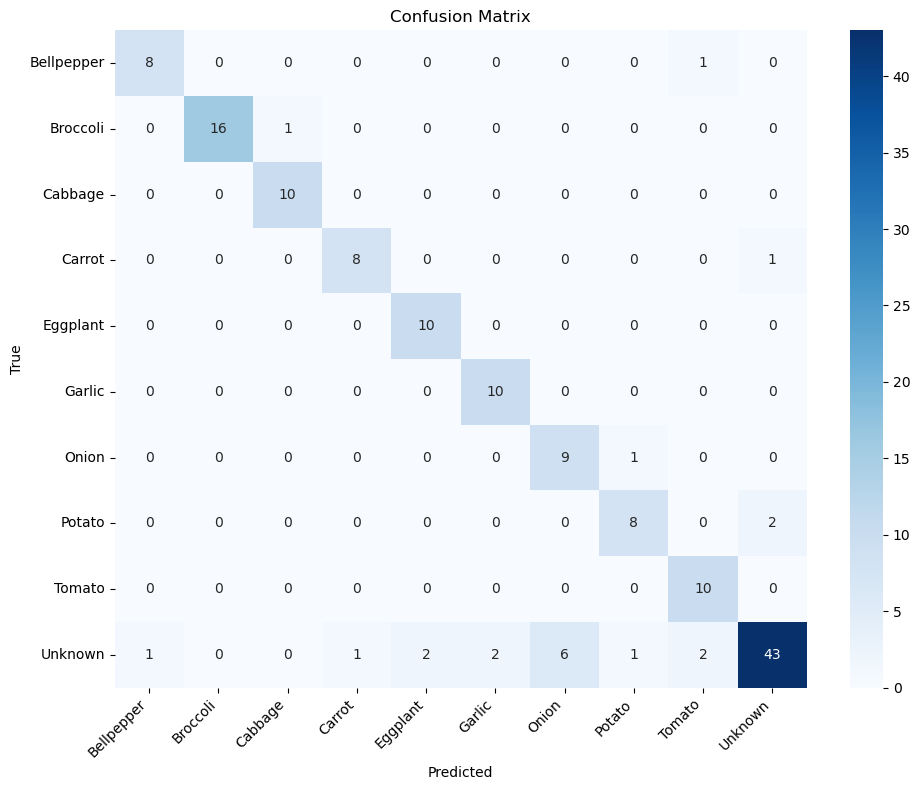

Overall accuracy: 0.8627


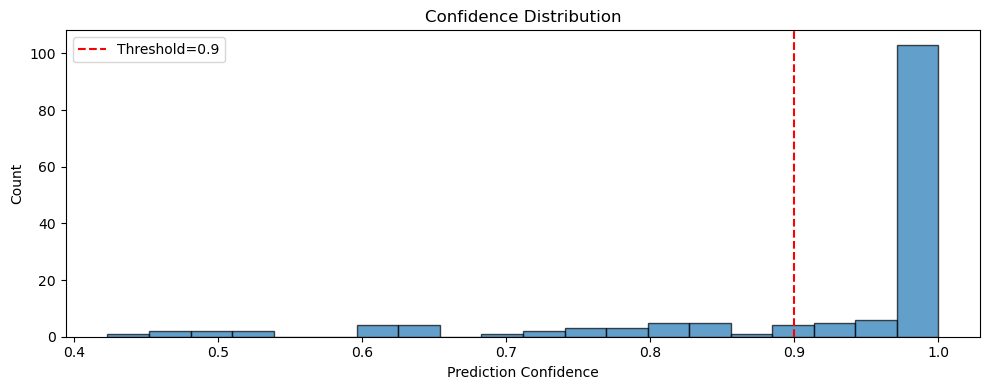

In [32]:
# Cell 10: Detailed per-class evaluation with confidence threshold

y_true, y_pred, y_conf = [], [], []
all_labels = list(range(len(class_names)))

for imgs, labels in val_ds:
    probs = best_model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_conf.extend(np.max(probs, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

unknown_mask = y_conf < CONFIDENCE_THRESHOLD
confident_mask = ~unknown_mask
print(f'Predictions below threshold ({CONFIDENCE_THRESHOLD}): {np.sum(unknown_mask)}/{len(y_true)}')
print('These would be "Object not known"\n')

if np.sum(confident_mask) > 0:
    print('=== Classification Report (confident predictions) ===')
    print(classification_report(
        y_true[confident_mask], y_pred[confident_mask],
        labels=all_labels, target_names=class_names, zero_division=0
    ))

print('=== Classification Report (all predictions) ===')
print(classification_report(
    y_true, y_pred,
    labels=all_labels, target_names=class_names, zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RUN_DIR / 'confusion_matrix.png', dpi=120)
plt.show()

accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f'Overall accuracy: {accuracy:.4f}')

plt.figure(figsize=(10, 4))
plt.hist(y_conf, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=CONFIDENCE_THRESHOLD, color='r', linestyle='--',
            label=f'Threshold={CONFIDENCE_THRESHOLD}')
plt.xlabel('Prediction Confidence'); plt.ylabel('Count')
plt.title('Confidence Distribution'); plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / 'confidence_hist.png', dpi=120)
plt.show()

In [37]:
# Cell 11: Export to TFLite INT8 (only artifact V4 produces - no SenseCraft variants)
#
# V4 quantization tweaks vs the original V3 export:
#   1. Preprocess as `Rescaling` (not Lambda). Lowers to a plain Mul+Add that gets folded
#      into the first Conv during conversion - no Cast/Lambda boundary that confuses
#      the int8 calibrator.
#   2. Class-balanced representative dataset. Old code took the first 200 of a shuffled
#      stream; with 10 classes that left some classes barely calibrated. Now we sample
#      ~50 stills per class (~500 total) so every class's activation distribution is seen.
#   3. Resize via tf.image.resize (bilinear) so calibration sees the same pixel statistics
#      training did, not PIL-resized variants.

# (1) Class-balanced representative dataset
REP_PER_CLASS = 50
def representative_dataset():
    rng_local = np.random.default_rng(SEED)
    for cls in SELECTED_CLASSES:
        files = sorted((MNV2_DATASET / 'train' / cls).glob('*'))
        if not files:
            continue
        picks = rng_local.choice(files,
                                 size=min(REP_PER_CLASS, len(files)),
                                 replace=False)
        for fp in picks:
            raw = tf.io.read_file(str(fp))
            img = tf.io.decode_image(raw, channels=3, expand_animations=False)
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))    # bilinear, matches train
            img = tf.expand_dims(tf.cast(img, tf.float32), 0)   # [1,H,W,3] in [0,255]
            yield [img]

# Quick sanity: how many calibration samples will we see?
_n_rep = sum(1 for _ in representative_dataset())
print(f'Representative dataset: {_n_rep} samples across {len(SELECTED_CLASSES)} classes')

# (2) Bake preprocess as Rescaling so calibrator can fold it into Conv1
raw_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='raw_input')
scaled = layers.Rescaling(scale=1.0/127.5, offset=-1.0, name='preprocess')(raw_in)
logits = best_model(scaled)
export_model = models.Model(raw_in, logits, name='mnv2_veggie_export')

converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_bytes = converter.convert()

tflite_path = Path('veggie_mnv2.tflite')
tflite_path.write_bytes(tflite_bytes)

tflite_size = tflite_path.stat().st_size
print(f'TFLite INT8 model: {tflite_path}')
print(f'Size: {tflite_size / 1024:.1f} KB ({tflite_size / (1024*1024):.2f} MB)')
print(f'Fits in ESP32S3 8MB flash: {"YES" if tflite_size < 4 * 1024 * 1024 else "NO"}')

# (3) FP16 sanity export - if FP16 ~ Keras then drop is purely 8-bit dynamic range,
#     not a pipeline bug. Not deployed to ESP32 (no fp16 support in TFLM micro builds);
#     used only as a reference number in Cell 12.
fp16_conv = tf.lite.TFLiteConverter.from_keras_model(export_model)
fp16_conv.optimizations = [tf.lite.Optimize.DEFAULT]
fp16_conv.target_spec.supported_types = [tf.float16]
tflite_fp16_path = Path('veggie_mnv2_fp16.tflite')
tflite_fp16_path.write_bytes(fp16_conv.convert())
print(f'FP16 reference model: {tflite_fp16_path} ({tflite_fp16_path.stat().st_size/1024:.1f} KB)')


2026-05-12 11:54:17.270471: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:54:18.147449: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


Representative dataset: 500 samples across 10 classes
INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpafa238zg/assets


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpafa238zg/assets


Saved artifact at '/var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpafa238zg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='raw_input')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  14751703376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14303737424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14303733776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14303731088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14749810768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338258000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338257616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338257808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338258960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338259920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338260688:

W0000 00:00:1778612062.152743 33439328 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778612062.152753 33439328 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-12 11:54:28.918016: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:54:30.668809: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


TFLite INT8 model: veggie_mnv2.tflite
Size: 624.9 KB (0.61 MB)
Fits in ESP32S3 8MB flash: YES
INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmp_9onfl_d/assets


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmp_9onfl_d/assets


Saved artifact at '/var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmp_9onfl_d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='raw_input')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  14751703376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14303737424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14303733776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14303731088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14749810768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338258000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338257616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338257808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338258960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338259920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13338260688:

W0000 00:00:1778612077.023911 33439328 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778612077.023920 33439328 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [38]:
# Cell 12: Validate TFLite model
#
# IMPORTANT: evaluate on the SAME pixels Keras saw, otherwise resize-algorithm
# differences (PIL bilinear vs TF bilinear-no-antialias) inflate the apparent drop.
# We feed val_ds_raw (uint8 batches Keras already produced) directly into the interpreter.

def eval_tflite(model_path, label):
    itp = tf.lite.Interpreter(model_path=str(model_path))
    itp.allocate_tensors()
    in_d, out_d = itp.get_input_details()[0], itp.get_output_details()[0]
    in_scale, in_zp = in_d['quantization']
    out_scale, out_zp = out_d['quantization']
    in_dtype = in_d['dtype']

    print(f'--- {label} ---')
    print(f'Input:  shape={in_d["shape"]}, dtype={in_dtype.__name__}, '
          f'q=(scale={in_scale}, zp={in_zp})')
    print(f'Output: shape={out_d["shape"]}, dtype={out_d["dtype"].__name__}, '
          f'q=(scale={out_scale}, zp={out_zp})')

    correct = total = 0
    for imgs, labels in val_ds_raw:                       # raw uint8, Keras-resized
        imgs_np = imgs.numpy().astype(np.float32)
        labels_np = labels.numpy()
        for img, lbl in zip(imgs_np, labels_np):
            if in_dtype in (np.int8, np.uint8):
                q = np.round(img / in_scale + in_zp).astype(in_dtype)
            else:                                          # float (fp16 export)
                q = img.astype(in_dtype)
            itp.set_tensor(in_d['index'], q[None])
            itp.invoke()
            out = itp.get_tensor(out_d['index'])
            if out_d['dtype'] in (np.int8, np.uint8):
                out = (out.astype(np.float32) - out_zp) * out_scale
            pred = int(np.argmax(out))
            correct += int(pred == int(lbl))
            total += 1
    acc = correct / max(total, 1)
    print(f'Accuracy: {acc:.4f}  ({correct}/{total})\n')
    return acc

int8_acc = eval_tflite(tflite_path,      'TFLite INT8 (deployed)')
fp16_acc = eval_tflite(tflite_fp16_path, 'TFLite FP16 (reference)')

print('=== Accuracy Comparison ===')
print(f'Keras MobileNetV2 (val_ds): {accuracy:.4f}')
print(f'TFLite FP16:                {fp16_acc:.4f}   (drop {(accuracy-fp16_acc)*100:+.2f}%)')
print(f'TFLite INT8:                {int8_acc:.4f}   (drop {(accuracy-int8_acc)*100:+.2f}%)')
print()
print('Reading the numbers:')
print('  - FP16 drop is the irreducible "converter loss" + any preprocess-folding glitch;')
print('    should be near 0. If it\'s > ~1pp, suspect the export wrapper (Cell 11).')
print('  - INT8 drop on top of FP16 is the true 8-bit dynamic-range cost; expect 1-3pp')
print('    on a well-calibrated MobileNetV2-0.35. Larger drops -> calibration is bad')
print('    (try more samples / better balance) or model is too narrow (try alpha=0.5).')


--- TFLite INT8 (deployed) ---
Input:  shape=[  1 128 128   3], dtype=int8, q=(scale=1.0, zp=-128)
Output: shape=[ 1 10], dtype=int8, q=(scale=0.00390625, zp=-128)
Accuracy: 0.8366  (128/153)

--- TFLite FP16 (reference) ---
Input:  shape=[  1 128 128   3], dtype=float32, q=(scale=0.0, zp=0)
Output: shape=[ 1 10], dtype=float32, q=(scale=0.0, zp=0)
Accuracy: 0.8562  (131/153)

=== Accuracy Comparison ===
Keras MobileNetV2 (val_ds): 0.8627
TFLite FP16:                0.8562   (drop +0.65%)
TFLite INT8:                0.8366   (drop +2.61%)

Reading the numbers:
  - FP16 drop is the irreducible "converter loss" + any preprocess-folding glitch;
    should be near 0. If it's > ~1pp, suspect the export wrapper (Cell 11).
  - INT8 drop on top of FP16 is the true 8-bit dynamic-range cost; expect 1-3pp
    on a well-calibrated MobileNetV2-0.35. Larger drops -> calibration is bad
    (try more samples / better balance) or model is too narrow (try alpha=0.5).


In [39]:
# Cell 13: Export C header for ESP32

def export_c_header(tflite_path, header_path, array_name='model_data'):
    with open(tflite_path, 'rb') as f:
        data = f.read()
    with open(header_path, 'w') as f:
        f.write('#ifndef MODEL_DATA_H\n')
        f.write('#define MODEL_DATA_H\n\n')
        f.write(f'const unsigned int {array_name}_len = {len(data)};\n\n')
        f.write(f'alignas(16) const unsigned char {array_name}[] = {{\n')
        for i in range(0, len(data), 12):
            chunk = data[i:i+12]
            hex_vals = ', '.join(f'0x{b:02x}' for b in chunk)
            f.write(f'  {hex_vals},\n')
        f.write('};\n\n')
        f.write('#endif // MODEL_DATA_H\n')
    print(f'Model header: {header_path} ({len(data)} bytes)')

def export_labels_header(class_names, header_path, threshold=CONFIDENCE_THRESHOLD):
    with open(header_path, 'w') as f:
        f.write('#ifndef LABELS_H\n')
        f.write('#define LABELS_H\n\n')
        f.write(f'const int NUM_CLASSES = {len(class_names)};\n')
        f.write(f'const float CONFIDENCE_THRESHOLD = {threshold}f;\n')
        f.write('const char* UNKNOWN_LABEL = "Object not known";\n\n')
        f.write('const char* LABELS[] = {\n')
        for name in class_names:
            f.write(f'  "{name}",\n')
        f.write('};\n\n')
        f.write('#endif // LABELS_H\n')
    print(f'Labels header: {header_path}')

export_c_header(tflite_path, 'model_data.h')
export_labels_header(class_names, 'labels.h')

print(f'\n=== Final Summary ===')
print(f'Model: MobileNetV2 alpha={ALPHA}, {IMG_SIZE}x{IMG_SIZE}, INT8')
print(f'TFLite size: {tflite_size / 1024:.1f} KB ({tflite_size / (1024*1024):.2f} MB)')
print(f'Classes: {class_names}')
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')
print(f'\nCopy model_data.h and labels.h into src/main/ to update the firmware.')

Model header: model_data.h (639912 bytes)
Labels header: labels.h

=== Final Summary ===
Model: MobileNetV2 alpha=0.35, 128x128, INT8
TFLite size: 624.9 KB (0.61 MB)
Classes: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato', 'Unknown']
Confidence threshold: 0.9

Copy model_data.h and labels.h into src/main/ to update the firmware.


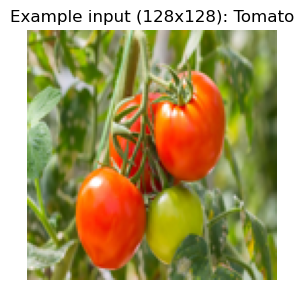

Saved: runs/veggie_mnv2/example_input_128x128.png  (34864 bytes)
Source: mnv2_dataset/val/Tomato/Tomato_1.jpg


In [40]:
# Cell 14: Save one example input image (for model upload / sanity test)

example_cls = 'Tomato'
src_files = sorted((MNV2_DATASET / 'val' / example_cls).glob('*'))
src_path = src_files[0]

example_img = Image.open(src_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
example_path = RUN_DIR / f'example_input_{IMG_SIZE}x{IMG_SIZE}.png'
example_img.save(example_path)

plt.figure(figsize=(3, 3))
plt.imshow(example_img)
plt.title(f'Example input ({IMG_SIZE}x{IMG_SIZE}): {example_cls}')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Saved: {example_path}  ({example_path.stat().st_size} bytes)')
print(f'Source: {src_path}')

## ESP32S3 Deployment Notes (V4)

### Sizing at 128x128
| | V3 (96x96) | V4 (128x128) |
|---|---|---|
| TFLite INT8 size | ~450 KB | ~700 KB (estimate) |
| Tensor arena needed | ~200-300 KB | ~350-450 KB |
| Inference time (ESP32S3, PSRAM arena) | ~150-400 ms | ~300-700 ms |

### Input convention
Same as V3: the exported TFLite takes **raw `int8` pixels mapped from [0,255]**;
`preprocess_input` ([-1,1] scaling) is baked in. ESP32 side: resize the QVGA
camera frame to 128x128 then quantise with the input scale/zero-point printed
by Cell 12.

### Update ESP32 sketch
Copy `model_data.h` and `labels.h` into `src/main/`, then in `src/main/main.ino`:
```cpp
constexpr int kInputSize = 128;                 // was 96 in V3 build
constexpr int kTensorArenaSize = 450 * 1024;    // bump from V3's 300 KB
```
Allocate the arena from PSRAM if SRAM is tight:
```cpp
uint8_t* tensor_arena = (uint8_t*)ps_malloc(kTensorArenaSize);
```